In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

In [2]:
# Plot
plot_directory = 'result/plot_set'

In [3]:
colors = [
	'#FF0000',
	# '#00FFFF',
	'#0000FF',
	'#00008B',
	# '#ADD8E6',
	'#800080',
	# '#7FFFD4',
	'#008000',
	'#FF00FF',
	'#FFC0CB',
	'#C0C0C0',
	'#FFA500',
	'#000000',
	'#800000',
]

In [4]:
def load_json_file(file_path):
	try:
		with open(file_path, 'r') as file:
			data = json.load(file)
		return data
	
	except Exception as e:
		print(f"An error occurred while loading the JSON file: {e}")
		return None

In [5]:
def extract_fpss(metric_list):
	return list(metric_list[list(metric_list.keys())[0]][0]['metric'].keys())

In [6]:
def to_accuracy_vector(accuracy_result_seq, fpss, type='F1'):
	accuracy_vector = []
	for fps in fpss:
		accuracy_vector.append(accuracy_result_seq[fps][type])
	
	return accuracy_vector

In [7]:
def plot_scatter(xs, ys, x_label, y_label, title, fig_size=(8, 8)):
	plt.figure(figsize=fig_size)
	plt.scatter(xs, ys, c=colors[0], s=30, alpha=0.5)
	plt.title(title)
	plt.xlabel(x_label)
	plt.ylabel(y_label)
	plt.show()

In [8]:
def plot_scatter_label(xs, ys, labels, x_label, y_label, title, fig_size=(8, 8)):
	plt.figure(figsize=fig_size)
	for i in range(len(xs)):
		plt.scatter(xs[i], ys[i], c=colors[labels[i]], s=30, alpha=0.5)
	plt.title(title)
	plt.xlabel(x_label)
	plt.ylabel(y_label)
	plt.show()

In [9]:
def filter_list_index(input_list, indices_to_remove):
	return [item for i, item in enumerate(input_list) if i not in indices_to_remove]

In [10]:
def round_float_to_sigfigs(number, sigfigs):
	return round(number, sigfigs)

## Plot

In [11]:
omv_features = ["Left-Top", "Right-Top", "Left-Bottom", "Right-Bottom", "Object-Amount", "Confidence", "IOU"]

In [12]:
plot_filenames = sorted(os.listdir(plot_directory))
plot_video_names = sorted(list(set([f.split('_')[0] for f in plot_filenames])))

In [13]:
fpss = extract_fpss(load_json_file(os.path.join(plot_directory, plot_video_names[0] + "_Accuracy_Result.json")))

In [14]:
omv_videos = []
acc_videos = []

for v in plot_video_names:
	omv_dict = {}
	for fps in fpss:
		omv_dict[fps] = []
	acc_list = []

	accuracy_result = load_json_file(os.path.join(plot_directory, v + "_Accuracy_Result.json"))
	movement_result = load_json_file(os.path.join(plot_directory, v + "_Movement_Result.json"))

	for class_idx in list(accuracy_result.keys()):
		for i in range(len(accuracy_result[class_idx])):
			accuracy_vector = to_accuracy_vector(accuracy_result[class_idx][i]['metric'], fpss)
			acc_list.append(accuracy_vector)

			for fps in fpss:
				movement_vector = movement_result[class_idx][i]['movement'][fps]
				omv_dict[fps].append(movement_vector)
	
	omv_videos.append(omv_dict)
	acc_videos.append(acc_list)

# New Code

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures

In [16]:
def transpose_array(arr):
    # Transpose the input array using zip and map it back to a list
    return [list(row) for row in zip(*arr)]

In [17]:
def my_train_test_split(x, y, test_size):
	split_point = int(len(x) * (1-test_size))
	return x[0:split_point], x[split_point:len(x)], y[0:split_point], y[split_point:len(x)]

In [18]:
def root_mean_squared_error(y_train, y_train_pred):
	return np.sqrt(mean_squared_error(y_train, y_train_pred))

In [19]:
OMV_FEATURE_INDEX = [5, 6]
TEST_SIZE = 0.2
TRAIN_VIDEO_NAMES = [
	'Video1',
	'Video2',
	'Video3',
	'Video4',
]
TEST_VIDEO_NAMES = [
	'Scene-1-Afternoon',
	'Scene-1-Day',
	'Scene-1-Night',
	'Scene-2-Afternoon',
	'Scene-2-Day',
	'Scene-2-Night',
]

In [20]:
# Dataset Build

dataset = {}

for i in range(len(plot_video_names)):
	video_name = plot_video_names[i]
	dataset[video_name] = {}
	
	for k in range(len(fpss)):
		fps = fpss[k]
		dataset[video_name][fps] = {}
		y_all = None
		x_all_t = []

		for j in range(len(omv_videos[0][fpss[0]][0])):	
			fps = fpss[k]

			omv_fps = list(np.array(omv_videos[i][fps])[:, j])
			acc_fps = list(np.array(acc_videos[i])[:, k])

			# Remove Outliers
			outlier_index = [l for l in range(len(omv_fps)) if omv_fps[l] == -1]
			omv_fps_clean = filter_list_index(omv_fps, outlier_index)
			acc_fps_clean = filter_list_index(acc_fps, outlier_index)

			if j == 0:
				y_all = acc_fps_clean.copy()
			if j in OMV_FEATURE_INDEX:
				x_all_t.append(omv_fps_clean.copy())
		
		x_all = transpose_array(x_all_t)
		dataset[video_name][fps]['y_all'] = y_all
		dataset[video_name][fps]['x_all'] = x_all
			

In [21]:
rmse_all_all = {}

for k in range(1, len(fpss)-1):
	fps = fpss[k]
	rmse_all_all[fps] = {}

	# Train
	x_train = []
	y_train = []
	for i in range(len(plot_video_names)):
		video_name = plot_video_names[i]
		if video_name in TRAIN_VIDEO_NAMES:
			x_train.extend(dataset[plot_video_names[i]][fps]['x_all'])
			y_train.extend(dataset[plot_video_names[i]][fps]['y_all'])
	
	lr_model = LinearRegression()
	lr_model.fit(x_train, y_train)

	for i in range(len(plot_video_names)):
		video_name = plot_video_names[i]
		if video_name not in TRAIN_VIDEO_NAMES:
			x_test = dataset[plot_video_names[i]][fps]['x_all']
			y_test = dataset[plot_video_names[i]][fps]['y_all']

			y_test_pred = lr_model.predict(x_test)
			test_rmse = root_mean_squared_error(y_test, y_test_pred)
			rmse_all_all[fps][video_name] = round(test_rmse, 3)

In [22]:
def print_2d_dict(d):
    """
    Nicely prints a 2D dictionary where elements are accessed by d[k1][k2].
    
    Parameters:
    d (dict): The 2D dictionary.
    
    Returns:
    None
    """
    # Extract unique k1 and k2 keys
    k1_keys = list(d.keys())
    k2_keys = list({k2 for sub_dict in d.values() for k2 in sub_dict.keys()})
    
    # Convert the 2D dict to a DataFrame
    data = {k1: [d.get(k1, {}).get(k2, None) for k2 in k2_keys] for k1 in k1_keys}
    df = pd.DataFrame(data, index=k2_keys).T
    
    # Print the DataFrame
    print(df)

In [23]:
def plot_mutiple_lines_horizontal(xs, yss, x_axis, y_axis, y_label_prefix, y_labels, title, label_size=28, font_size=32, legend_size=16, line_width=3):
	fig, ax1 = plt.subplots(figsize=(9, 6))
	
	for i in range(len(yss)):
		ax1.plot(xs, yss[i], color=colors[i], marker='o', label=f'{y_label_prefix}{y_labels[i]}')

	ax1.set_xlabel(x_axis, fontsize=font_size)
	ax1.set_ylabel(y_axis, fontsize=font_size)
	ax1.set_title(title, fontsize=font_size)
	plt.xticks(fontsize=label_size)
	plt.yticks(fontsize=label_size)
	plt.legend(fontsize=legend_size)
	plt.grid(True)

	plt.show()

In [26]:
MANUAL_FPS = fpss[1 : -1]
PERIOD = ['Day', 'Afternoon', 'Night']
VIDEO_PREFIX = ['Scene-1-', 'Scene-2-']

yss_1 = [[rmse_all_all[fps][f'{VIDEO_PREFIX[0]}{p}'] for p in PERIOD] for fps in MANUAL_FPS]
yss_2 = [[rmse_all_all[fps][f'{VIDEO_PREFIX[1]}{p}'] for p in PERIOD] for fps in MANUAL_FPS]

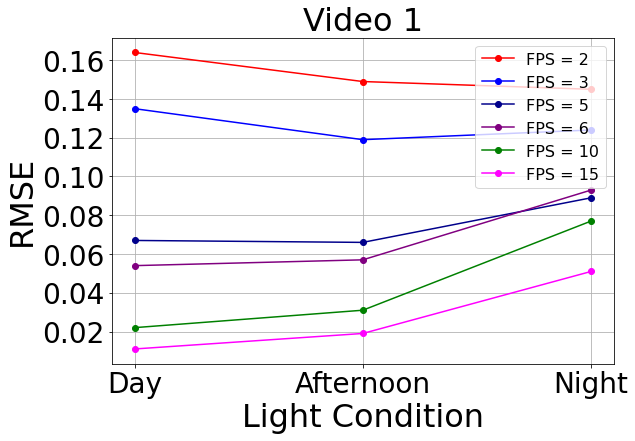

In [27]:
plot_mutiple_lines_horizontal(PERIOD, yss_1, 'Light Condition', 'RMSE', 'FPS = ', MANUAL_FPS, 'Video 1')
# plot_mutiple_lines_horizontal(PERIOD, yss_2, 'Light Condition', 'Prediction Model RMSE', 'FPS = ', MANUAL_FPS, 'Video 2')